In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
users=pd.read_csv("clean_users_dataset.csv")
logs=pd.read_csv("clean_logs_dataset.csv")

In [4]:
users.info()
logs.info()

<class 'pandas.DataFrame'>
RangeIndex: 1862 entries, 0 to 1861
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     1862 non-null   int64
 1   username    1862 non-null   str  
 2   department  1862 non-null   str  
dtypes: int64(1), str(2)
memory usage: 43.8 KB
<class 'pandas.DataFrame'>
RangeIndex: 1601 entries, 0 to 1600
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   log_id          1601 non-null   int64  
 1   user_id         1601 non-null   int64  
 2   query_type      1601 non-null   str    
 3   execution_time  1601 non-null   float64
 4   cpu_usage       1601 non-null   float64
 5   memory_usage    1601 non-null   float64
 6   execution_date  1601 non-null   str    
 7   status          1601 non-null   str    
dtypes: float64(3), int64(2), str(3)
memory usage: 100.2 KB


In [5]:
logs["execution_date"]=pd.to_datetime(logs["execution_date"])

logs.info()

<class 'pandas.DataFrame'>
RangeIndex: 1601 entries, 0 to 1600
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   log_id          1601 non-null   int64         
 1   user_id         1601 non-null   int64         
 2   query_type      1601 non-null   str           
 3   execution_time  1601 non-null   float64       
 4   cpu_usage       1601 non-null   float64       
 5   memory_usage    1601 non-null   float64       
 6   execution_date  1601 non-null   datetime64[us]
 7   status          1601 non-null   str           
dtypes: datetime64[us](1), float64(3), int64(2), str(2)
memory usage: 100.2 KB


In [6]:
df=pd.merge(logs,users,on="user_id",how="inner")

In [7]:
df.shape

df.info()

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1601 entries, 0 to 1600
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   log_id          1601 non-null   int64         
 1   user_id         1601 non-null   int64         
 2   query_type      1601 non-null   str           
 3   execution_time  1601 non-null   float64       
 4   cpu_usage       1601 non-null   float64       
 5   memory_usage    1601 non-null   float64       
 6   execution_date  1601 non-null   datetime64[us]
 7   status          1601 non-null   str           
 8   username        1601 non-null   str           
 9   department      1601 non-null   str           
dtypes: datetime64[us](1), float64(3), int64(2), str(4)
memory usage: 125.2 KB


,log_id,user_id,execution_time,cpu_usage,memory_usage,execution_date
count,1601.000000,1601.000000,1601.000000,1601.000000,1601.000000,1601
mean,999.241099,971.128670,1.119192,15.792074,29.425940,2026-04-12 02:08:37.176764
min,1.000000,1.000000,0.001600,0.100000,1.080000,2026-01-01 00:00:00
25%,506.000000,459.000000,0.400800,5.980000,14.250000,2026-02-13 00:00:00
50%,1003.000000,937.000000,1.088600,15.290000,28.350000,2026-03-23 00:00:00
75%,1496.000000,1483.000000,1.754800,24.820000,44.110000,2026-04-30 00:00:00
max,2000.000000,2000.000000,2.497700,34.970000,59.960000,2026-12-04 00:00:00
std,572.986365,582.769694,0.767776,10.621504,16.754342,NaN


In [8]:
total_queries=df["log_id"].count()
print(f'total_queries:-',total_queries)

avg_execution_time=round(df["execution_time"].mean(),2)
print(f'avg execution time:-',avg_execution_time,"sec")

avg_cpu_use=round(df["cpu_usage"].mean(),2)
print(f'avg cpu use:-',avg_cpu_use,"%")

avg_memory_usage=round(df["memory_usage"].mean())
print(f"avg memory usage:-",avg_memory_usage,"MB")

df['status'].unique()
success_rate=round(((df["status"] == "SUCCESS").mean())*100 , 2)
print(f"success rate:-",success_rate,"%")

failed_queries=(df["status"] == "FAILED").sum()
print(f"falied queries:-",failed_queries)

active_users=df["user_id"].nunique()
print(f'active users:-',active_users)

most_used_query=(df["query_type"].value_counts().idxmax())
print(f"most used query type:-",most_used_query)

fastest_query=df["execution_time"].min()
print(f"fastest query execution time:-",fastest_query,"msec")

slowest_query=df["execution_time"].max()
print(f"slowest query execution time:-",slowest_query,"sec")

most_active_department=df["department"].value_counts().idxmax()
print(f"most active department:-",most_active_department)


total_queries:- 1601
avg execution time:- 1.12 sec
avg cpu use:- 15.79 %
avg memory usage:- 29 MB
success rate:- 58.78 %
falied queries:- 336
active users:- 1097
most used query type:- UPDATE
fastest query execution time:- 0.0016 msec
slowest query execution time:- 2.4977 sec
most active department:- IT support


# KPI Insights

- The system processed a total of 1601 database queries after data cleaning and preprocessing.
- The average query execution time was approximately 1.12 seconds, indicating efficient overall query performance.
- Average CPU utilization remained moderate at 15.79%, suggesting balanced system resource consumption.
- Average memory usage was approximately 29 MB, showing stable memory allocation during query execution.
- The query success rate was 58.78%, while 336 queries failed, indicating opportunities for improving database reliability and query optimization.
- A total of 1097 active users interacted with the system, reflecting high user engagement across departments.
- UPDATE was the most frequently executed query type, suggesting the system handles significant transactional or modification-based operations.
- The fastest query executed in 0.0016 milliseconds, while the slowest completed in 2.49 seconds after outlier removal.
- IT Support emerged as the most active department, generating the highest number of database queries.

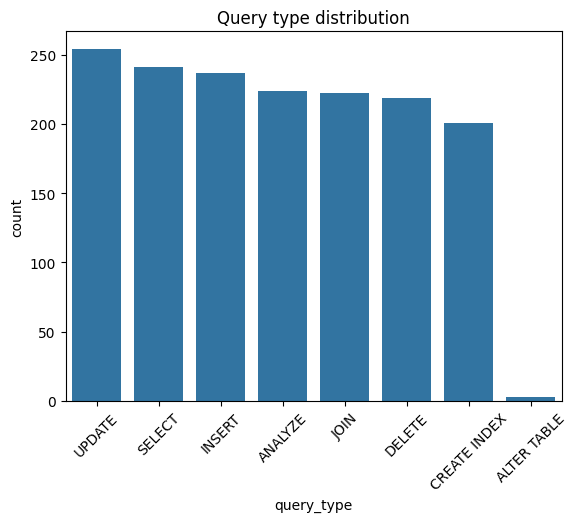

In [9]:
plt.Figure(figsize=(8,5))

sns.countplot(
  x=df["query_type"],
  order=df["query_type"].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Query type distribution")
plt.show()

# Query Type Distribution Insights

- UPDATE queries were executed most frequently, indicating high transactional activity within the system.
- SELECT and INSERT operations also contributed significantly to the workload, reflecting active data retrieval and data insertion processes.
- ALTER TABLE operations were very limited, suggesting schema modifications were rare during the observed period.
- The database workload contains a balanced mix of read, write, and analytical operations.

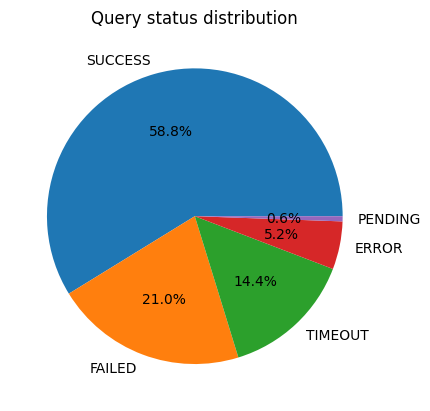

In [10]:
df["status"].value_counts().plot(
  kind="pie",
  autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Query status distribution")

plt.show()

# Query Status Insights

- More than half of the executed queries completed successfully, demonstrating generally stable database operations.
- FAILED and TIMEOUT queries together represented a notable portion of executions, indicating potential optimization opportunities.
- ERROR and PENDING statuses occurred less frequently, suggesting limited critical execution issues.
- Reducing failed and timeout queries could significantly improve overall system efficiency and reliability.

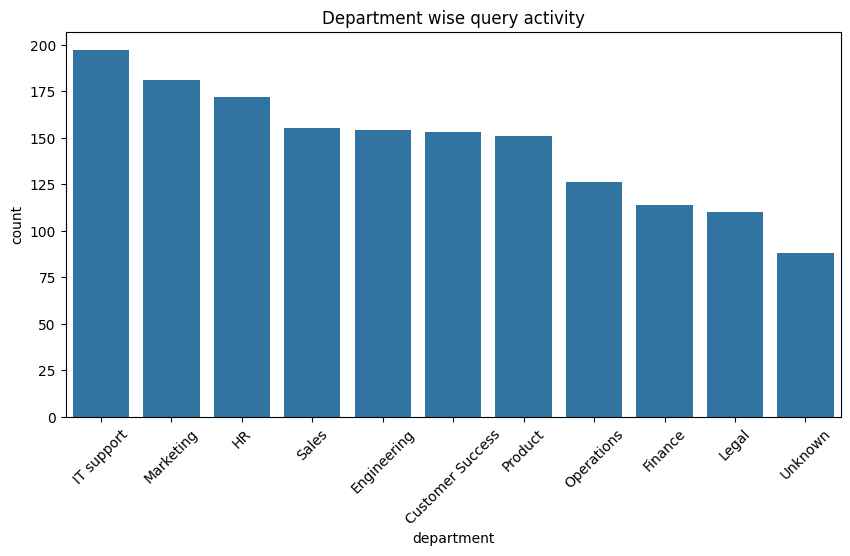

In [11]:
plt.figure(figsize=(10,5))

sns.countplot(
  x=df["department"],
  order=df["department"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Department wise query activity")

plt.show()

# Department-wise Activity Insights

- IT Support generated the highest query volume, indicating heavy operational dependency on database systems.
- Marketing, HR, and Sales departments also showed substantial database interaction.
- Finance and Legal departments generated comparatively lower query activity.
- The Unknown department category suggests some records may still contain incomplete department mapping.

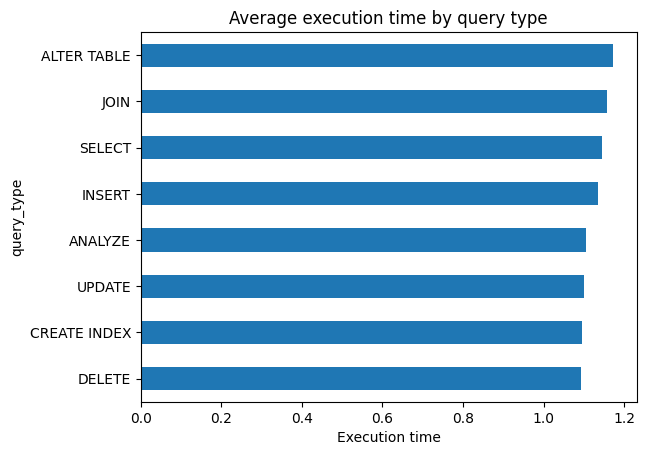

In [12]:
avg_exec=(
  df.groupby("query_type")["execution_time"].mean().sort_values()
)

avg_exec.plot(kind='barh')
plt.title("Average execution time by query type")
plt.xlabel("Execution time")
plt.show()

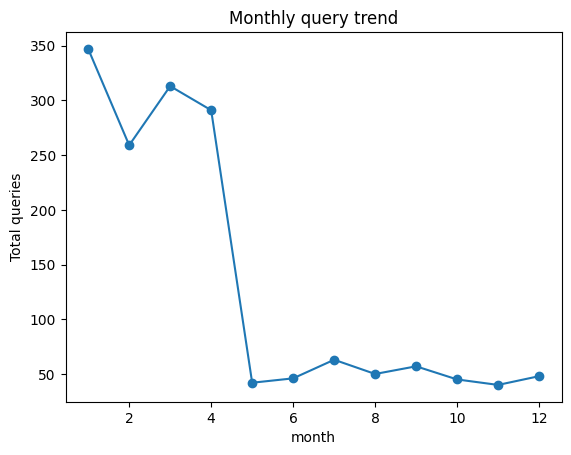

In [13]:
df["month"]=df["execution_date"].dt.month

monthly=(df.groupby("month")["log_id"].count())

monthly.plot(marker='o')

plt.title("Monthly query trend")
plt.ylabel("Total queries")
plt.show()

# Monthly Query Trend Insights

- Query activity was significantly higher during the first four months of the year.
- A sharp decline in query volume occurred after April, followed by relatively stable activity levels.
- January recorded the highest number of executed queries, representing peak system utilization.
- The trend suggests possible seasonal workload variation or changes in operational demand over time.

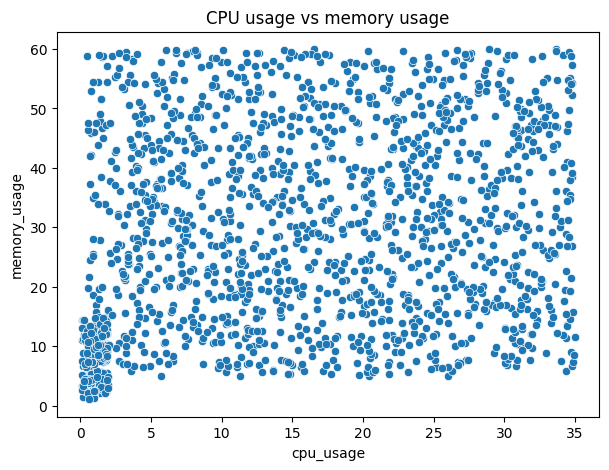

In [14]:
plt.figure(figsize=(7,5))

sns.scatterplot(
  x=df["cpu_usage"],
  y=df["memory_usage"]
)

plt.title("CPU usage vs memory usage")
plt.show()

# CPU vs Memory Usage Insights

- CPU usage and memory usage displayed a dispersed relationship without a very strong linear correlation.
- Most query executions consumed moderate CPU and memory resources.
- Several low CPU operations still consumed higher memory, indicating memory-intensive query patterns.
- System resource utilization remained within controlled and realistic ranges throughout execution.

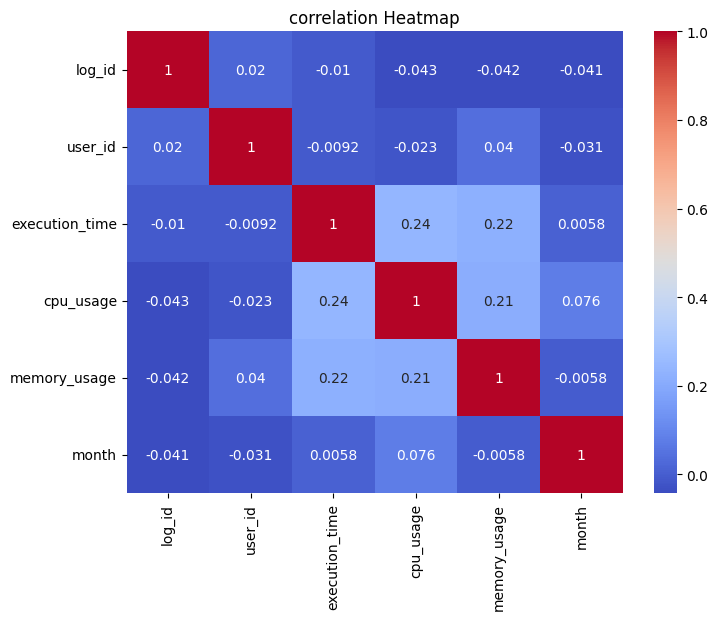

In [15]:
corr=df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(8,6))

sns.heatmap(
  corr,annot=True,cmap="coolwarm"
)

plt.title("correlation Heatmap")
plt.show()